# Analiza

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie do obliczeń: {device}")

Używane urządzenie do obliczeń: cuda


In [2]:
IMG_SIZE = 224

In [ ]:
data_dir = './Waste-Classification-1'

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(int(IMG_SIZE * 256/224)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(int(IMG_SIZE * 256/224)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'valid', 'test']
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x == 'train'), num_workers=2, pin_memory=True)
    for x in ['train', 'valid', 'test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid', 'test']}
class_names = image_datasets['train'].classes

for split in ['train', 'valid', 'test']:
    targets = image_datasets[split].targets
    print(f"{split} ({dataset_sizes[split]}):")
    for i, name in enumerate(class_names):
        print(f"  {name}: {targets.count(i)} ({targets.count(i) / dataset_sizes[split] * 100:.1f}%)")
    print()

train (1767):
  cardboard: 275 (15.6%)
  glass: 352 (19.9%)
  metal: 284 (16.1%)
  paper: 423 (23.9%)
  plastic: 340 (19.2%)
  trash: 93 (5.3%)

valid (504):
  cardboard: 84 (16.7%)
  glass: 102 (20.2%)
  metal: 85 (16.9%)
  paper: 107 (21.2%)
  plastic: 96 (19.0%)
  trash: 30 (6.0%)

test (253):
  cardboard: 44 (17.4%)
  glass: 47 (18.6%)
  metal: 40 (15.8%)
  paper: 64 (25.3%)
  plastic: 44 (17.4%)
  trash: 14 (5.5%)



# Definiowanie Modelu

In [4]:
class NikTechTrashClassificationCnn(nn.Module):
    def __init__(self, num_classes, img_size):
        super(NikTechTrashClassificationCnn, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        fc1_size = 256 * (img_size // 16) * (img_size // 16)
        self.fc1 = nn.Linear(fc1_size, 512)
        self.bn5 = nn.BatchNorm1d(512)
        
        self.dropout = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn5(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class_count = len(class_names)

model = NikTechTrashClassificationCnn(num_classes=class_count, img_size=IMG_SIZE).to(device)

print(model)
print(f"\nModel pomyślnie załadowany na urządzenie: {device}")

NikTechTrashClassificationCnn(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (bn5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_

# Pętla treningowa

In [5]:
#HIPERPARAMETRY
NUM_EPOCHS = 90
LEARNING_RATE = 0.0001

In [6]:
class_counts  = [image_datasets['train'].targets.count(i) for i in range(class_count)]
total         = sum(class_counts)
class_weights = torch.tensor(
    [total / (class_count * c) for c in class_counts],
    dtype=torch.float
).to(device)


criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5,
)

In [7]:
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':  []
}

best_val_acc    = 0.0
best_model_path =  f'best_model.pth'

In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()


        running_loss += loss.item() * images.size(0)
        _, predicted  = torch.max(outputs, 1)
        running_correct += (predicted == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch [{batch_idx+1}/{len(loader)}] Loss: {loss.item():.4f}")

    epoch_loss = running_loss / total
    epoch_acc  = running_correct / total
    return epoch_loss, epoch_acc


def validate_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            running_correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = running_correct / total
    return epoch_loss, epoch_acc



In [9]:
training_start = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print("-" * 40)

    train_loss, train_acc = train_epoch(
        model, dataloaders['train'], criterion, optimizer, device
    )

    val_loss, val_acc = validate_epoch(
        model, dataloaders['valid'], criterion, device
    )

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Trening: Loss {train_loss:.4f} | Acc: {train_acc*100:.2f}%")
    print(f"Walidacja: Loss: {val_loss:.4f}  | Acc: {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0  # NOWE
        torch.save({
            'epoch':           epoch + 1,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_acc':         best_val_acc,
            'class_names':     class_names,
            'img_size':        IMG_SIZE,
        }, best_model_path)
        print(f"Najlepszy model zapisany (acc: {best_val_acc*100:.2f}%)")

total_time = time.time() - training_start

print("\n" + "=" * 60)
print(f"Training skończony, najlepsza dokładnosc na zbiorze walidacyjnym: {best_val_acc*100:.2f}%")
print(f"Czas trenowania: {total_time//60:.0f}m {total_time%60:.0f}s")
print("=" * 60)


Epoch [1/90]
----------------------------------------
  Batch [10/56] Loss: 1.6596
  Batch [20/56] Loss: 1.5910
  Batch [30/56] Loss: 1.5482
  Batch [40/56] Loss: 1.4490
  Batch [50/56] Loss: 1.4288
Trening: Loss 1.5788 | Acc: 39.67%
Walidacja: Loss: 1.1620  | Acc: 57.14%
Najlepszy model zapisany (acc: 57.14%)

Epoch [2/90]
----------------------------------------
  Batch [10/56] Loss: 1.4208
  Batch [20/56] Loss: 1.2202
  Batch [30/56] Loss: 1.3025
  Batch [40/56] Loss: 1.2851
  Batch [50/56] Loss: 1.3988
Trening: Loss 1.3646 | Acc: 47.59%
Walidacja: Loss: 1.0277  | Acc: 62.30%
Najlepszy model zapisany (acc: 62.30%)

Epoch [3/90]
----------------------------------------
  Batch [10/56] Loss: 0.9737
  Batch [20/56] Loss: 1.2936
  Batch [30/56] Loss: 1.4236
  Batch [40/56] Loss: 1.4175
  Batch [50/56] Loss: 1.4172
Trening: Loss 1.3300 | Acc: 48.22%
Walidacja: Loss: 0.9642  | Acc: 66.47%
Najlepszy model zapisany (acc: 66.47%)

Epoch [4/90]
----------------------------------------
  Batc

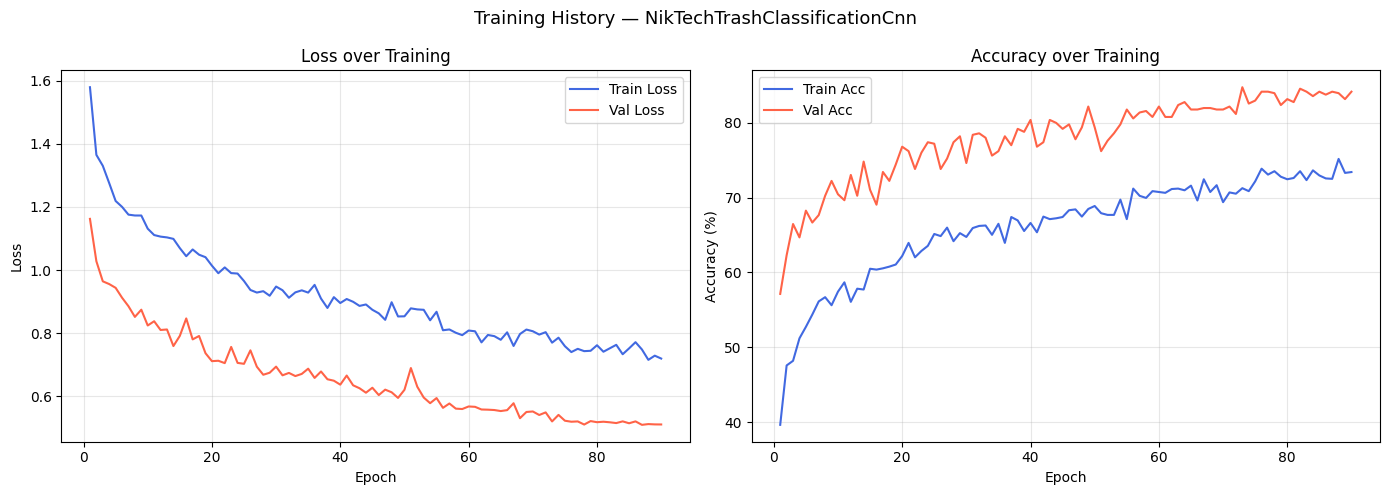

In [10]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='royalblue')
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato')
ax1.set_title('Loss over Training')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in history['train_acc']], label='Train Acc', color='royalblue')
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val Acc',   color='tomato')
ax2.set_title('Accuracy over Training')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training History — NikTechTrashClassificationCnn', fontsize=13)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Weryfikacja ze zbiorem testowym


In [11]:
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded best model from epoch {checkpoint['epoch']} (val acc: {checkpoint['val_acc']*100:.2f}%)")

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in dataloaders['test']:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

Loaded best model from epoch 73 (val acc: 84.72%)


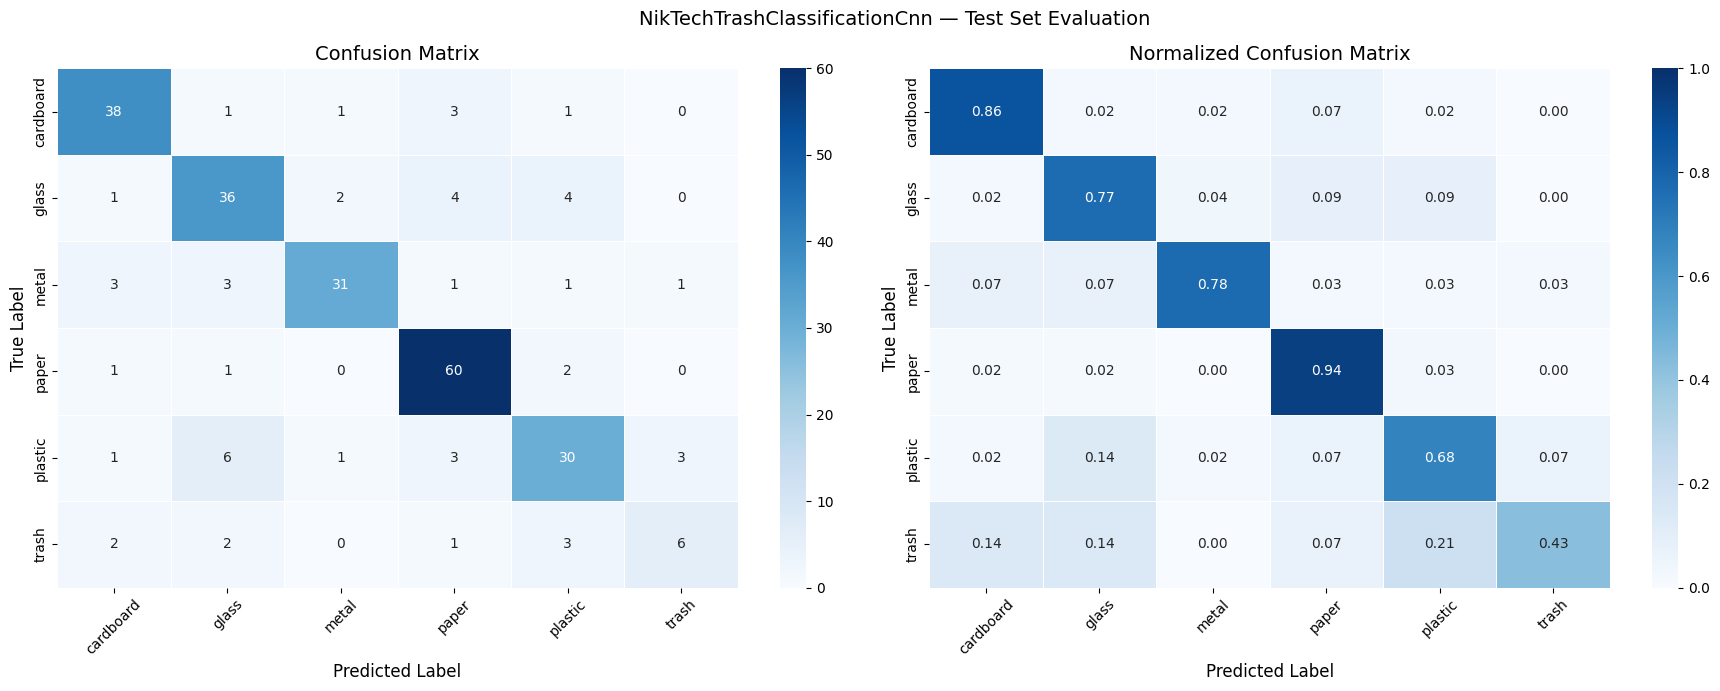

              precision    recall  f1-score   support

   cardboard     0.8261    0.8636    0.8444        44
       glass     0.7347    0.7660    0.7500        47
       metal     0.8857    0.7750    0.8267        40
       paper     0.8333    0.9375    0.8824        64
     plastic     0.7317    0.6818    0.7059        44
       trash     0.6000    0.4286    0.5000        14

    accuracy                         0.7945       253
   macro avg     0.7686    0.7421    0.7516       253
weighted avg     0.7914    0.7945    0.7905       253

Dokładność względem zbioru testowego 79.45%


In [12]:
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names, linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix', fontsize=14)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('NikTechTrashClassificationCnn — Test Set Evaluation', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
print(f"Dokładność względem zbioru testowego {(all_labels == all_preds).mean()*100:.2f}%")